# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [5]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float).reshape(-1)

    if A.ndim != 2:
        raise ValueError("A must be a 2D matrix")
    rows, cols = A.shape
    if rows != cols:
        raise ValueError("A must be square")
    if b.shape != (rows,):
        raise ValueError(
            f"b must contain one value per row of A. Input shape={b.shape}"
        )

    augmented = np.column_stack((A, b))
    steps = [augmented.copy()]

    if verbose:
        print("초기 첨가행렬 [A|b] =\n", augmente

In [6]:
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

초기 첨가행렬 [A|b] =
 [[ 3.  1.  2. 11.]
 [ 1.  4.  1.  1.]
 [ 2. -1.  5. 20.]]

0열 소거 (행 1)
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 2.       -1.        5.       20.      ]]

0열 소거 (행 2)
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]

1열 소거 (행 2)
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]

후진대입 해 x = [ 2. -1.  3.]


In [7]:
residual = A @ x - b
print("최종 해 x =", x)
print("정수해인가 =", np.allclose(x, np.round(x)))
print("A @ x =", A @ x)
print("잔차 norm =", np.linalg.norm(residual))
print("np.linalg.solve 비교 =", np.linalg.solve(A, b))  # 비교 대상

최종 해 x = [ 2. -1.  3.]
정수해인가 = True
A @ x = [11.  1. 20.]
잔차 norm = 3.580361673049448e-15
np.linalg.solve 비교 = [ 2. -1.  3.]


In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `b`가 `A`의 열공간에 있고 연립방정식은 일관된다.
- 다를 때: 첨가행렬의 rank가 더 커져 모순 행이 생기므로 해가 없다.
- 같지만 n 보다 작을 때: 자유변수가 생겨 해가 무한히 많다.

In [9]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]
print("rank(A), rank([A|b]), n =", rA, rAb, n_unknowns)
print("np.linalg.matrix_rank 비교 =", np.linalg.matrix_rank(A), np.linalg.matrix_rank(Ab))  # 검산용

b_bad = np.array([1.0, 1.0, 2.0])
b_ok = np.array([1.0, 3.0, 2.0])
for label, rhs in [("모순", b_bad), ("무모순 종속", b_ok)]:
    Ab_case = np.hstack([A_dep, rhs.reshape(-1, 1)])
    U, pivots, swaps = row_echelon(Ab_case)
    print(f"{label}: rank(A)={rank(A_dep)}, rank([A|b])={rank(Ab_case)}")
    print("마지막 소거 행 =", U[-1])

rank(A), rank([A|b]), n = 3 3 3
np.linalg.matrix_rank 비교 = 3 3
모순: rank(A)=2, rank([A|b])=3
마지막 소거 행 = [0.       0.       0.       0.666667]
무모순 종속: rank(A)=2, rank([A|b])=2
마지막 소거 행 = [0. 0. 0. 0.]


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: 작은 determinant로 나누므로 반올림 오차가 크게 증폭된다.
- 소거 관점: 작은 피벗으로 나누는 과정에서 큰 배율과 상쇄가 생겨 수치 오차가 커진다.
- 스케일 실험에서 관찰한 것: 행렬 전체를 스케일하면 det만 작아지고 조건수와 해의 상대오차는 거의 변하지 않는다.
- 실무 판정 기준과 그 의미: determinant보다 condition number를 사용하며, 큰 값일수록 입력 오차가 해에 크게 증폭된다.

In [11]:
detA = det(A)
invA = inverse_gauss_jordan(A)
print("det(A) =", detA, " / np.linalg.det =", np.linalg.det(A))  # 검산용
print("A^-1 =\n", invA)
print("np.linalg.inv 비교 =\n", np.linalg.inv(A))  # 검산용
print("A @ A^-1 =\n", A @ invA)
print("A^-1 @ b =", invA @ b, "(가우스 소거 해 =", x, ")")

det(A) = 42.0  / np.linalg.det = 42.00000000000001
A^-1 =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
np.linalg.inv 비교 =
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
A @ A^-1 =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
A^-1 @ b = [ 2. -1.  3.] (가우스 소거 해 = [ 2. -1.  3.] )


In [12]:
x_reference = np.linalg.solve(A, b)  # 비교 대상
scale_rows = []
print("\n전체 스케일 실험")
print("scale        det                 cond              rel_err")
for s in [1.0, 1e-1, 1e-2, 1e-3]:
    As, bs = s * A, s * b
    xs, _ = gauss_eliminate(As, bs)
    row = (s, det(As), np.linalg.cond(As), np.linalg.norm(xs - x_reference) / np.linalg.norm(x_reference))
    scale_rows.append(row)
    print("{:g}  {: .6e}  {: .6e}  {: .6e}".format(*row))

near_rows = []
print("\n거의 특이한 행렬 실험")
print("eps          det                 cond              rel_err")
for eps in np.logspace(-2, -12, 6):
    Ane = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])
    bne = np.array([3.0, 6.0 + eps])
    xne, _ = gauss_eliminate(Ane, bne, pivoting=True)
    row = (eps, det(Ane), np.linalg.cond(Ane), np.linalg.norm(xne - [1.0, 1.0]) / np.sqrt(2.0))
    near_rows.append(row)
    print("{: .3e}  {: .6e}  {: .6e}  {: .6e}".format(*row))


전체 스케일 실험
scale        det                 cond              rel_err
1   4.200000e+01   4.214603e+00   1.453623e-16
0.1   4.200000e-02   4.214603e+00   1.678499e-16
0.01   4.200000e-05   4.214603e+00   2.653941e-16
0.001   4.200000e-08   4.214603e+00   2.670476e-16

거의 특이한 행렬 실험
eps          det                 cond              rel_err
 1.000e-02   1.000000e-02   2.508010e+03   0.000000e+00
 1.000e-04   1.000000e-04   2.500080e+05   0.000000e+00
 1.000e-06   1.000000e-06   2.500001e+07   0.000000e+00
 1.000e-08   1.000000e-08   2.500000e+09   0.000000e+00
 1.000e-10   1.000000e-10   2.499989e+11   0.000000e+00
 1.000e-12   1.000089e-12   2.497608e+13   0.000000e+00


In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- 작은 피벗 $\varepsilon$으로 나누면 소거 배율이 $1/\varepsilon$처럼 커진다. 이후 큰 수끼리 빼면서 유효숫자가 상쇄되고, 부분 피벗팅은 크기가 큰 1을 피벗으로 골라 이 증폭을 막는다.

In [14]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])
    x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)
    rel_err_no = np.linalg.norm(x_no - exact) / np.linalg.norm(exact)
    rel_err_pp = np.linalg.norm(x_pp - exact) / np.linalg.norm(exact)
    return exact, x_no, x_pp, rel_err_no, rel_err_pp


EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print("eps=1e-5")
print("참해       =", exact)
print("무피벗 해  =", x_no, "상대오차 =", err_no)
print("피벗팅 해  =", x_pp, "상대오차 =", err_pp)

errs_no, errs_pp = [], []
print("\neps          err(no pivot)       err(partial pivot)")
for eps in eps_list:
    _, _, _, err_no_i, err_pp_i = solve_eps(eps)
    errs_no.append(max(err_no_i, 1e-18))
    errs_pp.append(max(err_pp_i, 1e-18))
    print("{: .3e}    {: .6e}          {: .6e}".format(eps, errs_no[-1], errs_pp[-1]))

eps=1e-5
참해       = [1.00001 0.99999]
무피벗 해  = [1.00001 0.99999] 상대오차 = 2.6901964197197188e-12
피벗팅 해  = [1.00001 0.99999] 상대오차 = 0.0

eps          err(no pivot)       err(partial pivot)
 1.000e-02     3.297026e-15           1.570012e-16
 1.000e-03     1.601494e-14           1.000000e-18
 1.000e-04     1.989307e-13           1.570092e-16
 1.000e-05     2.690196e-12           1.000000e-18
 1.000e-06     3.983796e-12           1.570092e-16
 1.000e-07     3.563319e-10           1.000000e-18
 1.000e-08     3.518027e-09           1.570092e-16
 1.000e-09     2.070545e-08           1.000000e-18
 1.000e-10     5.843557e-08           1.000000e-18
 1.000e-11     5.849921e-08           1.000000e-18
 1.000e-12     1.564242e-05           1.000000e-18
 1.000e-13     2.198715e-04           1.570092e-16
 1.000e-14     5.651748e-04           1.000000e-18
 1.000e-15     5.651748e-04           1.570092e-16
 1.000e-16     8.629857e-01           1.570092e-16


/tmp/ipykernel_29057/2181646887.py:13: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/2181646887.py:13: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/2181646887.py:13: UserWarning: Glyph 48279 (\N{HANGUL SYLLABLE BEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/2181646887.py:13: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/2181646887.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/2181646887.py:13: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/2181646887.py:13: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.t

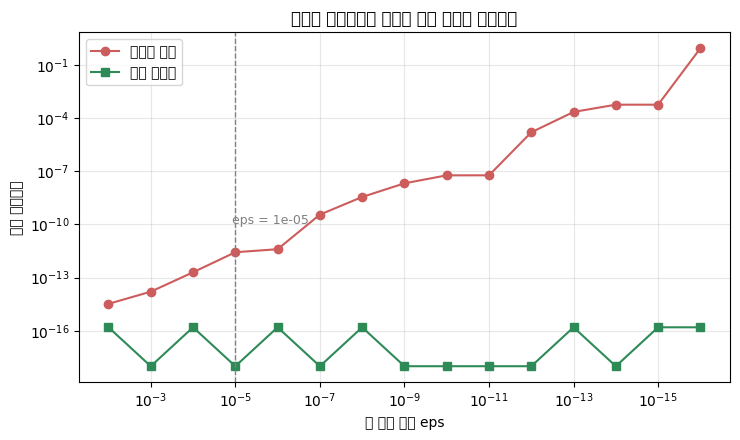

In [15]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [16]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `solve`는 한 번의 LU 분해와 대입(O(n^3))이고, 역행렬은 n개 우변을 푸는 비용으로 더 크다.
- 정확도: `solve`가 불필요한 역행렬 계산을 피하므로 보통 더 안정적이다.
- 메모리: 역행렬은 추가로 n×n 저장공간이 필요하고 `solve`는 상대적으로 작다.
- 우변이 여러 개일 때는: 분해를 한 번 재사용해 `solve(A, B)`로 여러 우변을 함께 푼다.
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: 실제로 $A^{-1}$ 자체가 결과로 필요하거나 반복적인 행렬 연산에 재사용해야 할 때뿐이다.

In [17]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big)
res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)
inverse_memory_mb = N * N * 8 / (1024 ** 2)
print("method       time [ms]       residual")
print("solve        {: .3f}       {: .6e}".format(1e3 * t_solve, res_solve))
print("inv @ b      {: .3f}       {: .6e}".format(1e3 * t_inv, res_inv))
print("explicit inverse storage: {:.2f} MiB".format(inverse_memory_mb))

method       time [ms]       residual
solve         8.722        8.000724e-12
inv @ b       28.126        1.618627e-11
explicit inverse storage: 4.88 MiB


In [18]:
N_cond = 120
Q1, _ = np.linalg.qr(rng.standard_normal((N_cond, N_cond)))
Q2, _ = np.linalg.qr(rng.standard_normal((N_cond, N_cond)))
x_cond_true = rng.standard_normal(N_cond)
condition_rows = []
print("target_cond       solve_rel_err       inv_rel_err")
for target_cond in [1e2, 1e6, 1e10, 1e14]:
    sv = np.logspace(0.0, -np.log10(target_cond), N_cond)
    A_cond = (Q1 * sv) @ Q2.T
    b_cond = A_cond @ x_cond_true
    xs_cond = np.linalg.solve(A_cond, b_cond)
    xi_cond = np.linalg.inv(A_cond) @ b_cond
    row = (target_cond, np.linalg.norm(xs_cond - x_cond_true) / np.linalg.norm(x_cond_true), np.linalg.norm(xi_cond - x_cond_true) / np.linalg.norm(x_cond_true))
    condition_rows.append(row)
    print("{: .1e}           {: .6e}        {: .6e}".format(*row))

target_cond       solve_rel_err       inv_rel_err
 1.0e+02            5.956940e-15         2.092194e-14
 1.0e+06            1.477117e-11         7.415082e-11
 1.0e+10            6.051432e-08         4.100110e-07
 1.0e+14            1.110912e-03         4.332719e-03


/tmp/ipykernel_29057/3207582863.py:20: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/3207582863.py:20: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/3207582863.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/3207582863.py:20: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/3207582863.py:20: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/3207582863.py:20: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29057/3207582863.py:20: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fi

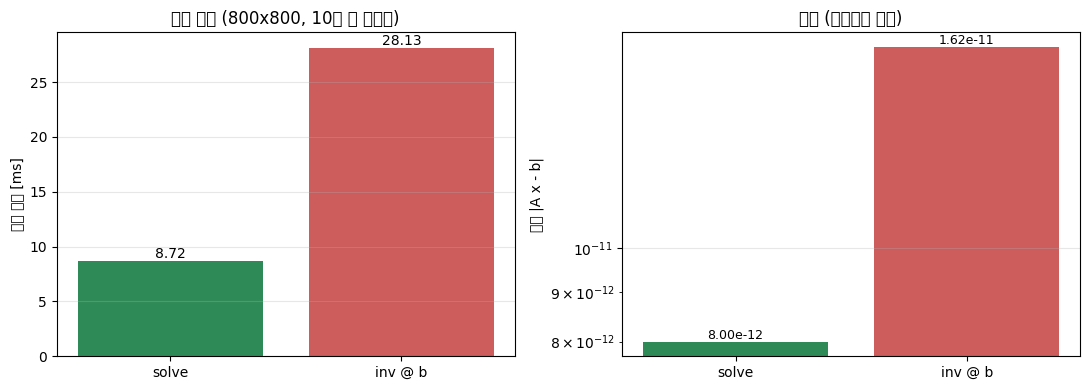

In [19]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [20]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [21]:
summary = f"""
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}

2. rank A: {rA} / rank 첨가행렬: {rAb}   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank가 3으로 같으므로 유일해
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 일관 / 해 없음 / 무한히 많은 해

3. 행렬식: {detA}
   역행렬:
   {np.array2string(invA, precision=6, suppress_small=True)}
   - det 이 0 에 가까울 때 위험한 이유: 작은 피벗 또는 det로 나누며 오차가 증폭됨
   - 실제 판정 기준: condition number

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): {err_no:.6e} / {err_pp:.6e}
   - eps 를 더 줄이면: 무피벗 오차가 커지고 부분 피벗팅은 안정적
   - 유효숫자가 날아가는 지점: 큰 소거 배율 뒤 큰 수끼리 빼는 단계

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : {t_solve * 1e3:.3f} ms / {t_inv * 1e3:.3f} ms
   - 잔차 : {res_solve:.6e} / {res_inv:.6e}
   - 조건수를 키웠을 때의 정확도 차이: 두 방법 모두 악화되지만 역행렬 곱이 대체로 더 민감함
   - 결론: 일반적인 Ax=b 문제에는 solve를 사용
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank가 3으로 같으므로 유일해
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 일관 / 해 없음 / 무한히 많은 해

3. 행렬식: 42.0
   역행렬:
   [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: 작은 피벗 또는 det로 나누며 오차가 증폭됨
   - 실제 판정 기준: condition number

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690196e-12 / 0.000000e+00
   - eps 를 더 줄이면: 무피벗 오차가 커지고 부분 피벗팅은 안정적
   - 유효숫자가 날아가는 지점: 큰 소거 배율 뒤 큰 수끼리 빼는 단계

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : 8.722 ms / 28.126 ms
   - 잔차 : 8.000724e-12 / 1.618627e-11
   - 조건수를 키웠을 때의 정확도 차이: 두 방법 모두 악화되지만 역행렬 곱이 대체로 더 민감함
   - 결론: 일반적인 Ax=b 문제에는 solve를 사용

